In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.integrate import solve_ivp

import tinyDA as tda

# forward model evaluations

import pyvista as pv
import ufl
from dolfinx import fem, mesh, plot, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI


from ufl import dx, grad, inner

from helpers import interpolate_nonmatching, plot_function
import pyvista

In [2]:
#!pip install tinyda

def extract_parameters(list):
    output = []
    for element in list:
        output.append(element.parameters.tolist()[0])

    return(np.array(output))

## Forward Model Setup

In [3]:
class LinearElasticity:
    def __init__(self, solve_mesh: mesh, observation_mesh: mesh) -> None:
        self._observation_mesh = observation_mesh
        self._mesh = solve_mesh
        self._V = fem.functionspace(self._mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        self._V_observation = fem.functionspace(self._observation_mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        # boundary conditions
        facets_left = mesh.locate_entities_boundary(
            self._mesh,
            dim=(self._mesh.topology.dim - 1),
            marker=lambda x: np.isclose(x[0], 0.0),
        )
        dofs_left = fem.locate_dofs_topological(
            V=self._V, entity_dim=self._mesh.topology.dim - 1, entities=facets_left
        )
        bc_left = fem.dirichletbc(
            value=default_scalar_type((0,0)), dofs=dofs_left, V=self._V
        )


        # coefficient setup
        u = ufl.TrialFunction(self._V)
        v = ufl.TestFunction(self._V)
        f = fem.Constant(self._mesh, default_scalar_type((0,-0.1)))
        x = ufl.SpatialCoordinate(self._mesh)
        lam = 1
        self._mu1 = fem.Constant(self._mesh, default_scalar_type(1))
        self._mu2 = fem.Constant(self._mesh, default_scalar_type(5))
        self._mu3 = fem.Constant(self._mesh, default_scalar_type(10))

        def mu(x):
            left = np.min(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            right = np.max(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            width = right-left
            return ufl.conditional(x[0]<=left+width/3, self._mu1, ufl.conditional(x[0]<=left + 2 * width/3, self._mu2, self._mu3) )

        def epsilon(u):
            return 1/2 * (ufl.grad(u) + ufl.grad(u).T)
        def sigma(u):
            return lam * ufl.nabla_div(u) * ufl.Identity(len(u)) + mu(x) * epsilon(u)

        

        # weak formulation
        a = inner(sigma(u), epsilon(v)) * dx
        L = inner(f, v) * dx  # + inner(g, v) * ds # only dirichlet

        self._problem = LinearProblem(
            a,
            L,
            bcs=[bc_left],
            petsc_options={"ksp_type": "cg", "pc_type": "gamg"},
            petsc_options_prefix="lp",
        )

        # performance optimization
        self._cells_V_to = np.arange(
            self._V_observation.mesh.topology.index_map(
                self._V_observation.mesh.topology.dim
            ).size_local,
            dtype=np.int32,
        )
        self._interpolation_data = fem.create_interpolation_data(
            self._V_observation, self._V, self._cells_V_to
        )
        
    def _evaluate(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the PDE solution operator S."""
        self._mu1.value = state
        self._mu2.value = 5 #state[1]
        self._mu3.value = 5 #state[2]
        sol = self._problem.solve()
        return sol

    def __call__(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the observation operator"""
        pde_sol = self._evaluate(state)
        observed = interpolate_nonmatching(
            self._V_observation,
            self._V,
            pde_sol,
            self._interpolation_data,
            self._cells_V_to,
        )
        return observed.x.array, 0 # placeholder for qoi

    @property
    def gdim(self):
        return self._mesh.geometry.dim

    @property
    def ndofs(self):
        return self._V.dofmap.index_map.size_global

    def plot(self, solution):
        """Plot forward model output, indicate regions of different mu."""


        def mu(x):
            left = np.min(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            right = np.max(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            width = right-left
            return np.where(x[:,0]<=left+width/3, self._mu1.value, np.where(x[:,0]<=left + 2 * width/3, self._mu2.value, self._mu3.value) )

        p = pyvista.Plotter()
        topology, cell_types, geometry = plot.vtk_mesh(self._V_observation)
        grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

        # Attach vector values to grid and warp grid by vector
        u_2d = solution.reshape((geometry.shape[0], 2))
        u_3d = np.column_stack([u_2d, np.zeros(u_2d.shape[0])])  # Add z=0 component

        # Plot material coefficient mu(x) (here: mu(theta(x)/eps) with theta(x)=[x1,x0] => depends on x1/eps)
        mu_vals = mu(geometry)

        grid["u"] = u_3d
        grid["mu"] = mu_vals
        warped = grid.warp_by_vector("u", factor=1.5)

        # Show only the outer boundary (no element edges)
        boundary = grid.extract_feature_edges(
            boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False)
        actor_0 = p.add_mesh(boundary, color="k", line_width=2)

        # Show the full deformed beam (no element edges)
        actor_1 = p.add_mesh(warped, scalars="mu", cmap="plasma", show_edges=True)
        p.add_scalar_bar(title="mu")
        p.show_axes()
        if not pyvista.OFF_SCREEN:
            p.show()
        else:
            figure_as_array = p.screenshot("deflection.png")



In [4]:
# UNIFORM REFINEMENT

_msh = mesh.create_unit_square(MPI.COMM_WORLD, 20, 20)
_msh.topology.create_entities(1)

_msh2 = mesh.refine(_msh)[0]

_obs_msh = mesh.create_unit_square(MPI.COMM_WORLD, 10, 10)

In [5]:
# MODEL HIERARCHY

model1 = LinearElasticity(_msh, _obs_msh)
model2 = LinearElasticity(_msh2, _obs_msh)

## Inverse Problem Setup

In [6]:
# set true parameter(s)

mu1 = 10
mu2 = 5
mu3 = 5

true_parameters = np.array([mu1])#, mu2, mu3]) # no log

x_true = model2(true_parameters)[0] # true displacement
x_true.shape

# generate data

sigma = 0.01

noise = np.random.normal(scale=sigma, size=(x_true.shape[0]))
data = x_true+noise

In [7]:
model2.plot(data)

Widget(value='<iframe src="http://localhost:57464/index.html?ui=P_0x304f719a0_0&reconnect=auto" class="pyvista…

In [8]:
#uniform_prior = stats.uniform(loc=np.log(0.5), scale=bnp.log(1.5)-np.log(0.5))
#uniform_prior = stats.uniform(loc=0, scale=2)

prior_mu1 = stats.uniform(loc=0, scale=100)
#prior_mu2 = stats.uniform(loc=0, scale=100)
#prior_mu3 = stats.uniform(loc=0, scale=100)

#my_prior = tda.CompositePrior([prior_mu1, prior_mu2, prior_mu3])

In [9]:
cov_likelihood = sigma**2*np.eye(data.size)

loglike = tda.GaussianLogLike(data, cov_likelihood)

In [10]:
my_posterior = tda.Posterior(prior_mu1, loglike, model2)

In [11]:
MAP = tda.get_MAP(my_posterior)
print(MAP)


/Users/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


[12.41468022]


In [12]:
MAP

array([12.41468022])

In [13]:
# random walk Metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# Adaptive Metropolis
#am_cov = np.eye(true_parameters.size)
#am_t0 = 100
#am_sd = None
#am_epsilon = 1e-6
#am_adaptive = True
#my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

#dream_m0 = 1000
#dream_delta = 1
#dream_Z_method = 'lhs'
#dream_adaptive = True
#my_proposal = tda.DREAMZ(M0=dream_m0, delta=dream_delta, Z_method=dream_Z_method, adaptive=dream_adaptive)

In [14]:
my_chain = tda.sample(my_posterior, my_proposal, iterations=3000, n_chains=2, initial_parameters=np.array(5), force_sequential=True)

Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [00:28<00:00, 107.13it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [00:27<00:00, 108.58it/s]


In [15]:
my_chain

{'sampler': 'MH',
 'n_chains': 2,
 'iterations': 3001,
 'chain_0': [<tinyDA.link.Link at 0x304f70b90>,
  ...],
 'chain_1': [<tinyDA.link.Link at 0x30a246150>,
  ...]}

In [ ]:
import arviz as az
samples = tda.get_samples(my_chain, burnin=2000)

idata = tda.to_inference_data(my_chain, burnin=1000)#, parameter_names = ['mu1'])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

: 

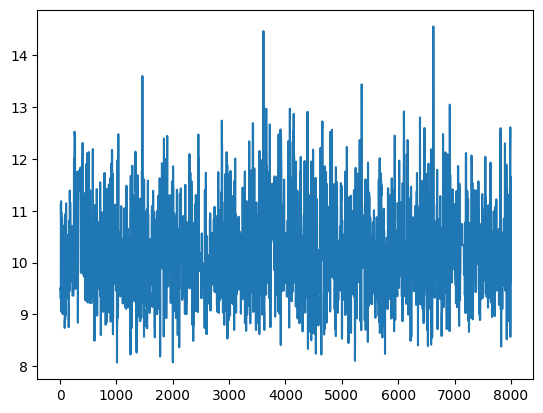

In [25]:
plt.plot(samples['chain_0'])

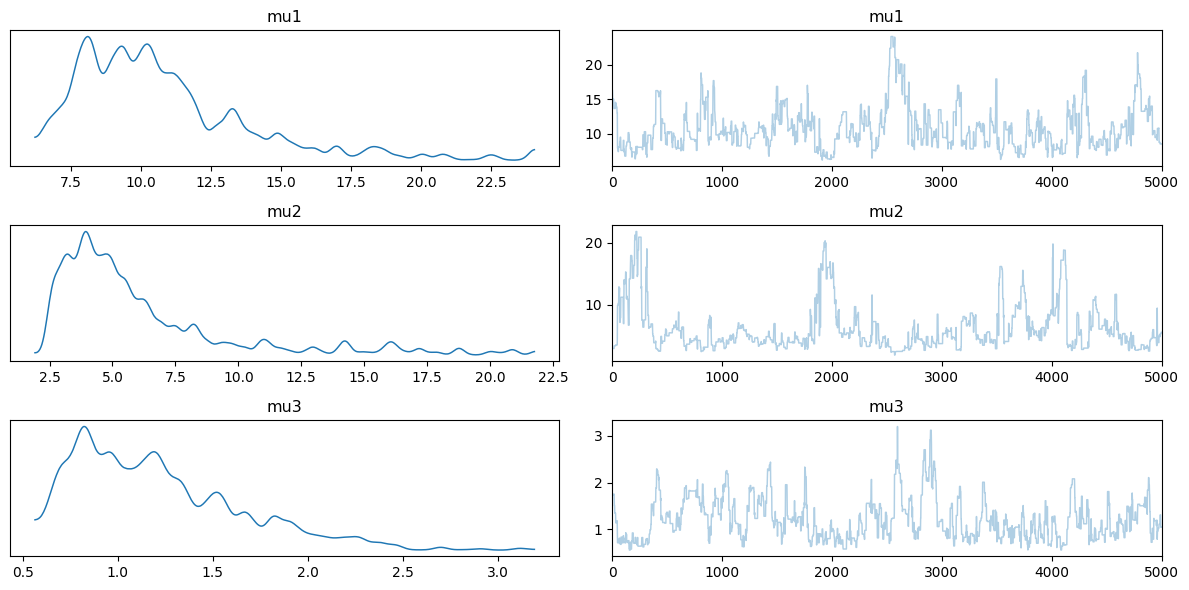

In [ ]:
az.plot_trace(idata)
plt.tight_layout()
plt.show()

In [36]:
import corner

figure = corner.corner(idata, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)


ModuleNotFoundError: No module named 'corner'